# `model_compare.py`

按功能分段；每段前有标题，方便查找和修改。

### Imports & constants

In [1]:
# compare_models.py

import pandas as pd
import matplotlib.pyplot as plt

from neural_backtest import summary_table

### Model result files

In [2]:
files = {
    "Long-Only": "longonly_oos_daily_returns.csv",
    "MACD-Baz2015": "macd_oos_daily_returns.csv",
    "MLP-Sharpe": "mlp_oos_daily_returns.csv",
    "LSTM-Sharpe": "lstm_oos_daily_returns.csv",
}

### Load OOS returns & compute summary

In [3]:
results = {}
returns = {}


for name, path in files.items():

    df = pd.read_csv(
        path,
        parse_dates=["Date"],
        index_col="Date",
    )

    r = df["rescaled_return"].dropna()

    returns[name] = r

    results[name] = summary_table(r)

### Summary table

In [4]:
summary = pd.DataFrame(results).T

print("\n=== OOS PERFORMANCE ===\n")

print(summary.round(4))

summary.to_csv(
    "neural_model_comparison.csv"
)


=== OOS PERFORMANCE ===

              E[Return]    Vol.  Downside Deviation     MDD  Sharpe  Sortino  \
Long-Only        0.0757  0.1554              0.1195  0.3759  0.4870   0.6332   
MACD-Baz2015     0.0588  0.1559              0.1228  0.3720  0.3775   0.4791   
MLP-Sharpe       0.1005  0.1591              0.1342  0.3580  0.6320   0.7494   
LSTM-Sharpe      0.1005  0.1564              0.1250  0.2901  0.6427   0.8037   

              Calmar  % +ve Returns  Ave.P/Ave.L  
Long-Only     0.2013         0.5392       0.9281  
MACD-Baz2015  0.1582         0.5437       0.8964  
MLP-Sharpe    0.2808         0.5480       0.9269  
LSTM-Sharpe   0.3464         0.5485       0.9237  


### Equity-curve plot


Saved neural_model_comparison.csv
Saved neural_equity_curves.png


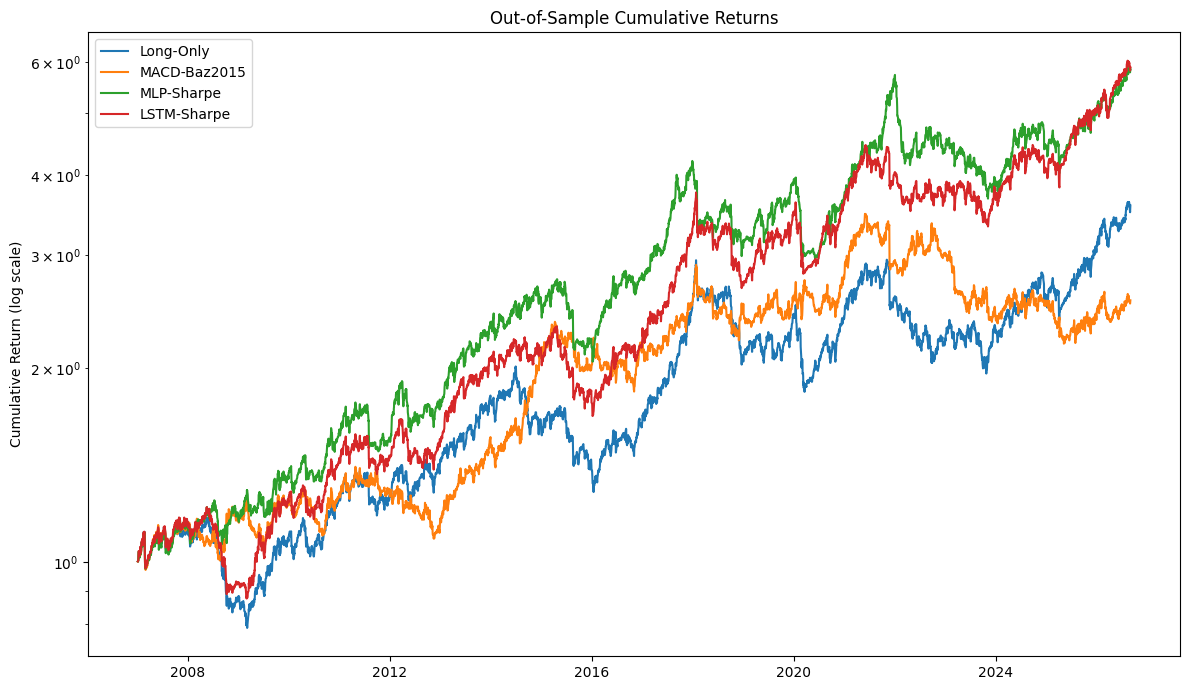

In [5]:
plt.figure(figsize=(12, 7))

for name, r in returns.items():

    equity = (1 + r).cumprod()

    plt.plot(
        equity.index,
        equity,
        label=name,
    )


plt.yscale("log")

plt.title(
    "Out-of-Sample Cumulative Returns"
)

plt.ylabel(
    "Cumulative Return (log scale)"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "neural_equity_curves.png",
    dpi=160,
)

print(
    "\nSaved neural_model_comparison.csv"
)

print(
    "Saved neural_equity_curves.png"
)